Script Overview
==============================================================================

Research Objective
------------------
To assess the degree of synchrony between Australia’s year-on-year Consumer
Price Index (CPI, 1993 – 2023) and year-on-year changes in victim counts for
fourteen offence categories recorded by the ABS.  The goal is to identify
crime types whose incidence rises or falls most noticeably in tandem with
inflation.

Key Data
--------
* **Inflation** – quarterly CPI from the Reserve Bank of Australia, averaged to
  calendar-year values and converted to annual growth rates.
* **Crime** – national victim numbers retrieved via the ABS Victim API for each
  offence category; likewise converted to year-on-year growth rates.
  An additional variable **sum** represents the total number of victims across
  all categories.

Analytical Procedure (abridged)
-------------------------------
1. Merge the CPI series with the crime series on integer year keys.
2. Compute percentage year-on-year changes (`pct_change`) for every column.
3. For each crime, plot a min–max-normalised line chart beside CPI to visualise
   co-movement.
4. Compute the Pearson correlation matrix on all growth series; display the
   lower triangle as a heat-map and extract the CPI column as a bar chart to
   highlight relative correlation strengths.

Key Findings
------------
* **Strong positive link** – *Blackmail / Extortion* (ρ ≈ +0.54).
* **Moderate positive links** – *Murder*, *Sexual Assault*, *Unlawful Entry
  with Intent*, *Motor-Vehicle Theft* (ρ ≈ +0.25 – 0.33).
* **Near-zero links** – *Attempted Murder*, *Kidnapping / Abduction*.
* **Marked negative links** – *Armed Robbery*, *Robbery*, *Unarmed Robbery*
  (ρ ≈ −0.33 to −0.36).
* The aggregate victim count (**sum**) shows only a weak positive correlation
  with CPI (ρ ≈ +0.17).

Preliminary Conclusion
----------------------
Inflation exerts a heterogeneous influence on crime.  Offences connected to
economic stress or opportunity—such as extortion, break-ins and certain violent
acts—tend to rise with CPI, whereas robbery-related crimes move inversely or
not at all.  Macro-level price changes are therefore not a universal driver of
criminal activity.  Future work should incorporate unemployment, policing
resources and other controls, and employ lagged regressions or causality tests
to scrutinise underlying mechanisms.


In [35]:
"""
Team 71
Yifu Chen 1609437,  Kexing Ma 1697372, Jiejun Xie 1418316, Xinhe Liu 1477404, Anqi Liao 1578312
"""

from copy import copy
from typing import Literal
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from black.trans import defaultdict
from urllib3.exceptions import InsecureRequestWarning
import warnings
import requests
import seaborn as sns

warnings.filterwarnings("ignore", category=InsecureRequestWarning)
warnings.filterwarnings(
    "ignore", message=r".*using TLS with verify_certs=False is insecure.*"
)

ES_HOSTS: list = [
    "https://127.0.0.1:9200",
    "https://192.168.99.200:9200",
    "https://elasticsearch-master.elastic:9200",
]
ES_HOST = ES_HOSTS[1]

API_HOSTS: list = [
    "http://192.168.99.200:9876"
]
API_HOST = API_HOSTS[0]

In [36]:
def get_victim_data(state="total", method: Literal["rate", "person"] = "rate"):
    """
    /victim/{state}/{method}
    state筛选某个州，或取值total。
    method选person或rate，指受害者人数，或100 000人中的受害者数。
    得到json报文的"Data"键值是list数据，每个数据是dict，
    其中"Offence"键值是受害种类，还有"1993"到"2023"的键，对应值是这些年份的数据。
    """

    url = f"{API_HOST}/victim/{state}/{method}"
    resp_0 = requests.get(url, timeout=10)

    if resp_0.ok:
        victims = resp_0.json().get("Data", [])
        return victims
    else:
        raise RuntimeError(resp_0.text)


def get_cpi(start, end):
    url = f"{API_HOST}/inflation/rba"
    if start and end:
        url += f"?start={start}&end={end}"
    elif not start and not end:
        pass
    elif start and not end:
        url += f"?start={start}"
    else:
        url += f"?end={end}"

    resp_0 = requests.get(url, timeout=10)
    if resp_0.ok:
        return resp_0.json()
    else:
        raise RuntimeError(resp_0.text)


In [7]:
# es = Elasticsearch(
#     hosts=[ES_HOST],
#     basic_auth=("elastic", "elastic"),
#     verify_certs=False
# )
#
# es_query = {"match_all": {}}
# resp = es.search(index="crime_victim_selected_year_state", size=9999, query=es_query)
#
# msg: dict = resp["hits"]
# msg_data: list = msg["hits"]

In [37]:
dt: list = get_victim_data(state="total", method="person")
all_offence = [dic["Offence"] for dic in dt]


In [38]:
ddic = defaultdict(list)
df_index = []
whether_collect_df_index = True
for dic_i in dt:
    offence = dic_i["Offence"]
    for k in sorted(dic_i):
        if k != "Offence":
            ddic[offence].append(dic_i[k])
            if whether_collect_df_index:
                df_index.append(k)
    if whether_collect_df_index:
        whether_collect_df_index = not whether_collect_df_index

In [39]:
crime_df = pd.DataFrame(ddic, index=df_index)
crime_df["sum"] = crime_df.sum(axis=1, numeric_only=True)
crime_by_year = crime_df
# crime_by_year = copy(crime_df["sum"])
crime_by_year.index = pd.to_datetime(crime_by_year.index).year

In [40]:
cpi_data = get_cpi(start="1993-01-01", end="2023-12-31")

In [41]:
cpi_date_value = {}
for dic_i in cpi_data:
    src = dic_i["_source"]
    date = src["date"]
    value = src["Consumer price index"]
    cpi_date_value[date] = value
cpi_date_value = pd.Series(
    cpi_date_value.values(),
    cpi_date_value.keys(),
    name="cpi",
)
cpi_date_value.index = pd.to_datetime(cpi_date_value.index)
cpi_by_year = cpi_date_value.resample("YE").mean()
cpi_by_year.index = cpi_by_year.index.year


In [42]:
main_df = pd.concat([cpi_by_year, crime_by_year], axis=1)

In [43]:

main_df.drop("Involving the taking of property", axis=1, inplace=True)
main_df.drop("Other theft", axis=1, inplace=True)
main_df.drop("Other", axis=1, inplace=True)


def get_pct_change(df):
    df = df.pct_change()
    df = df.iloc[1:, :]
    return df


def sub_df_contains_cpi(df, col_i):
    assert col_i > 0
    keep_cols = ["cpi", df.columns[col_i]]
    return copy(df[keep_cols])


def min_max_norm(df):
    number_df = df.select_dtypes(include='number')  # 选数值列视图
    df[number_df.columns] = (number_df - number_df.min()) / (number_df.max() - number_df.min())
    return df


def show_df(df):
    ax = df.plot(figsize=(10, 6),  # 自动为每列选不同颜色
                 linewidth=1.5,
                 marker='o',
                 markersize=3)
    ax.set_title("Year-by-year comparison of all series")
    ax.set_xlabel("Year")
    ax.set_ylabel("Value")
    ax.legend(title="Series", ncol=2)  # ncol 调多一点可减小拥挤
    plt.tight_layout()
    plt.show()


In [19]:
def show_corr(corr):
    mask = np.triu(
        np.ones_like(corr, dtype=bool)
    )

    plt.figure(figsize=(8, 6))
    sns.set_theme(style="white")

    sns.heatmap(
        corr,
        mask=mask,
        cmap="coolwarm",
        vmin=-1, vmax=1,
        square=True,
        linewidths=.5,
        cbar_kws={"label": "-1~1"},
        # annot=True,
        fmt=".2f"
    )

    plt.title(f"Corr Heat-map", pad=16)
    plt.tight_layout()
    plt.show()


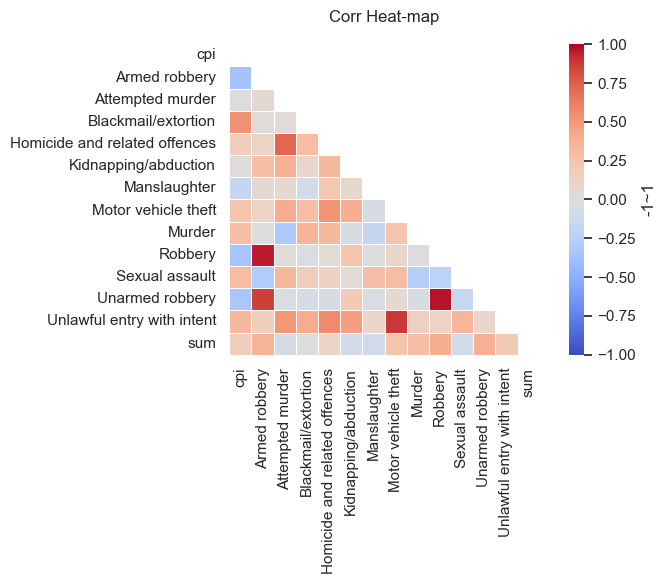

In [29]:
temp_df = main_df

temp_df = get_pct_change(temp_df)
corr_0 = temp_df.corr(
    # method="spearman"
)
show_corr(corr_0)


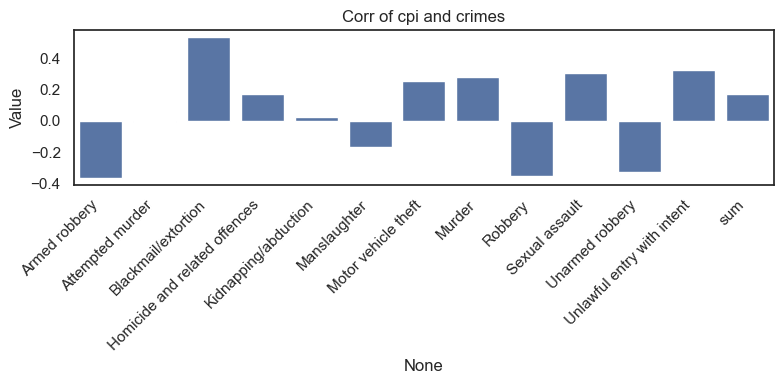

In [34]:
cpi_corr: pd.Series = corr_0.loc["cpi"]
cpi_corr.drop("cpi", inplace=True)

# ser 是 pandas.Series
plt.figure(figsize=(8, 4))

sns.barplot(
    x=cpi_corr.index,
    y=cpi_corr.values,
    color="#4c72b0"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.title("Corr of cpi and crimes")
plt.tight_layout()
plt.show()


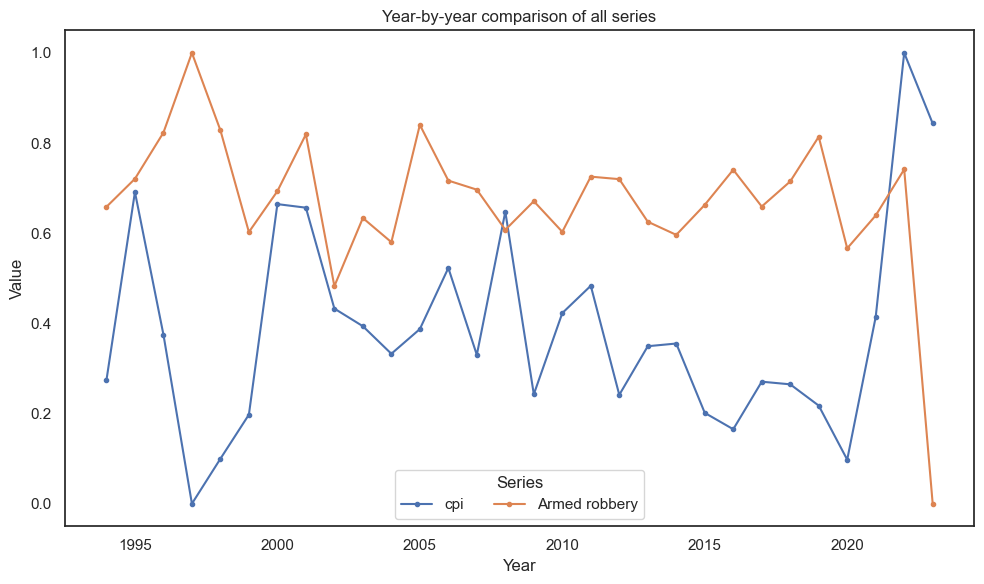

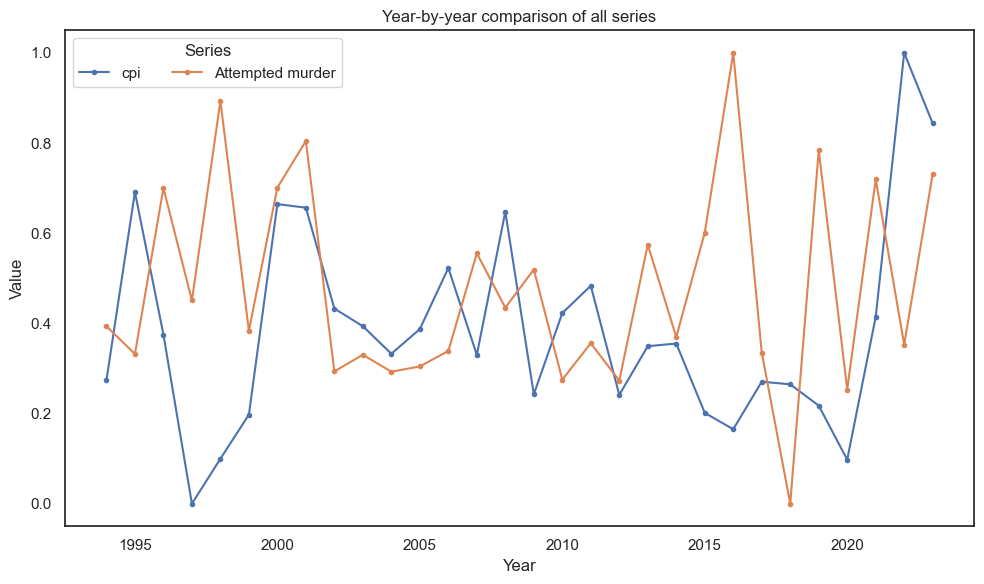

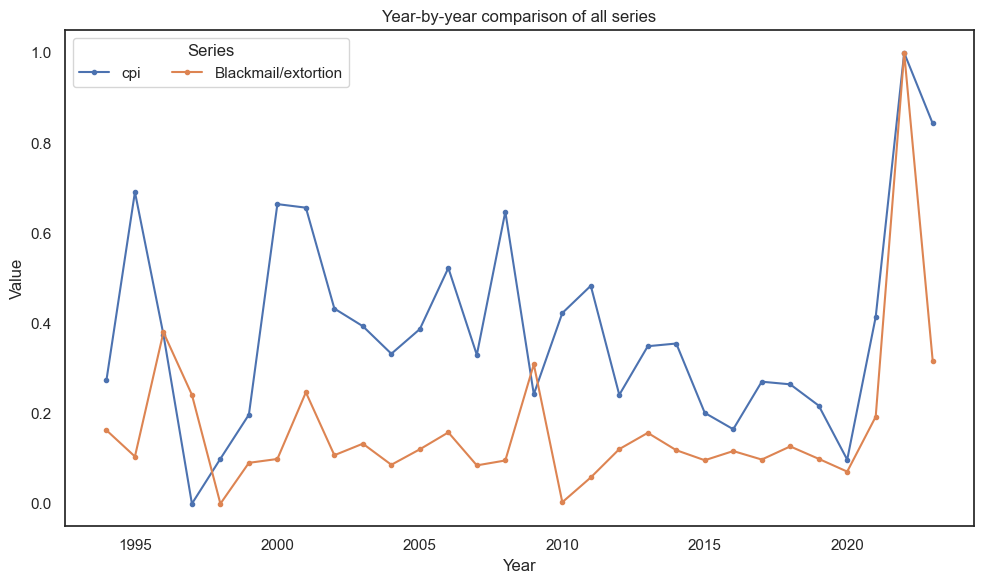

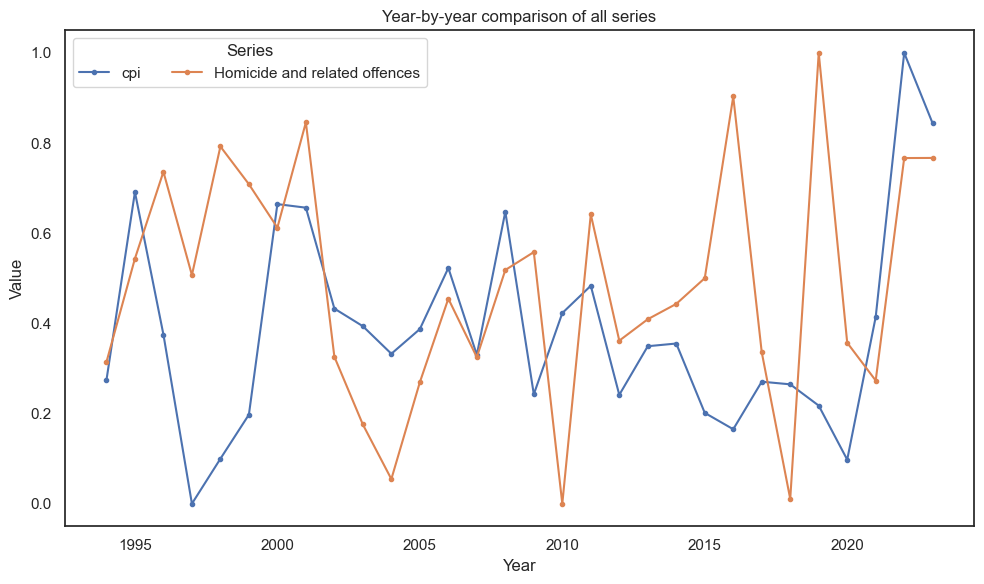

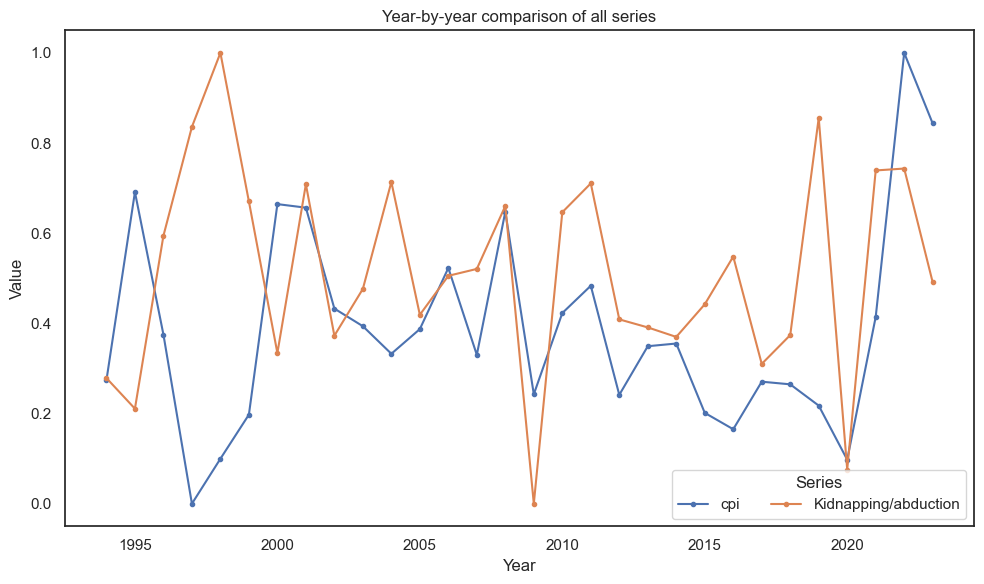

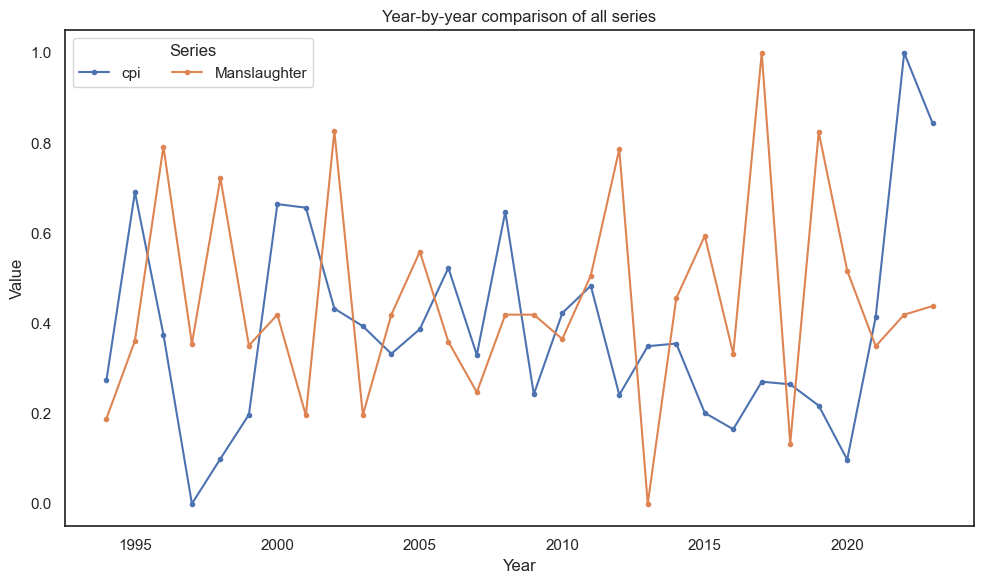

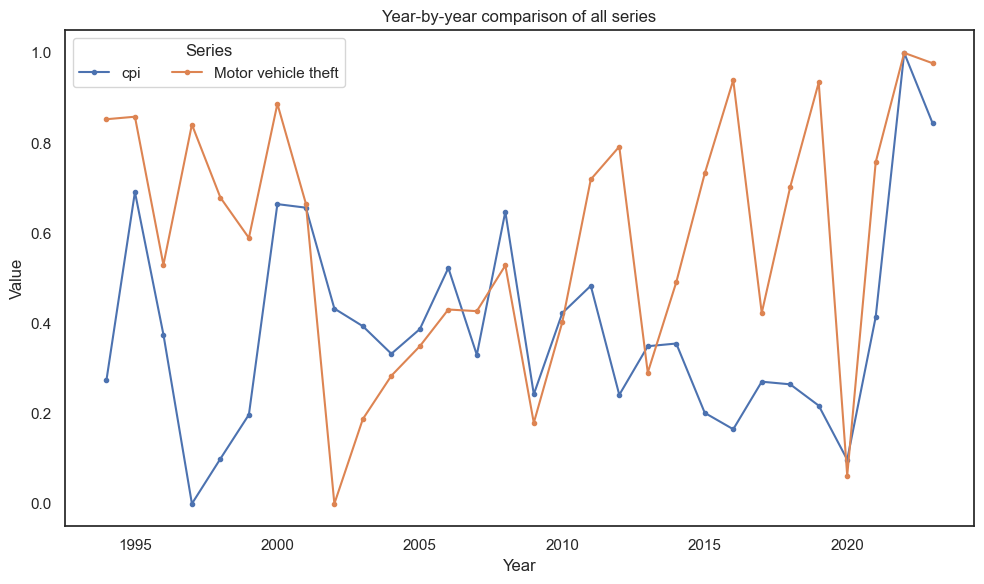

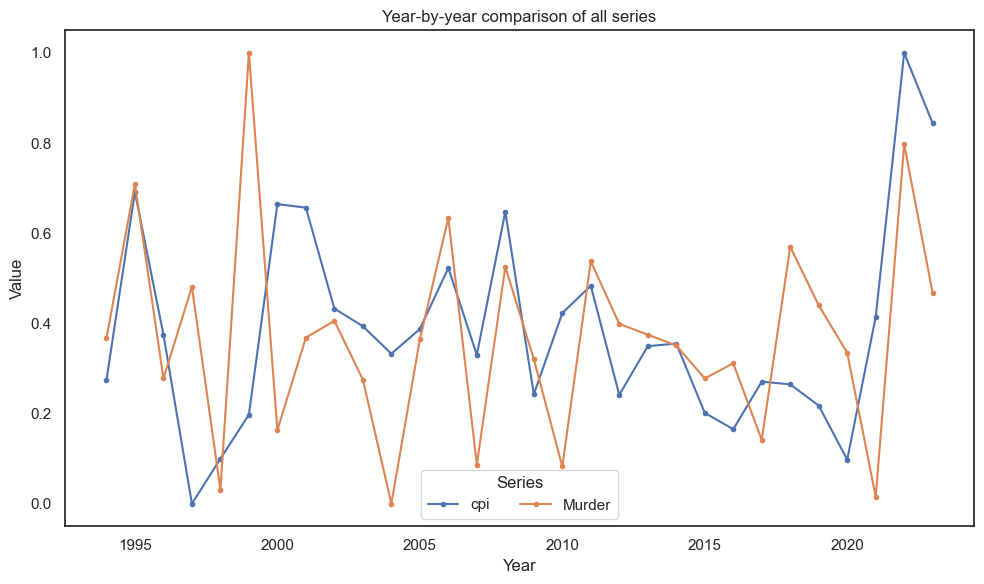

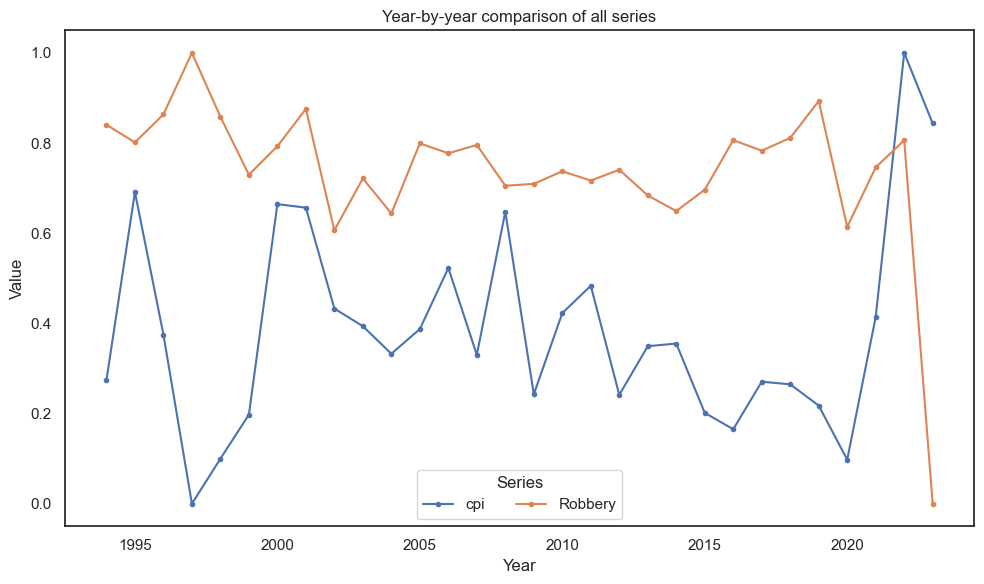

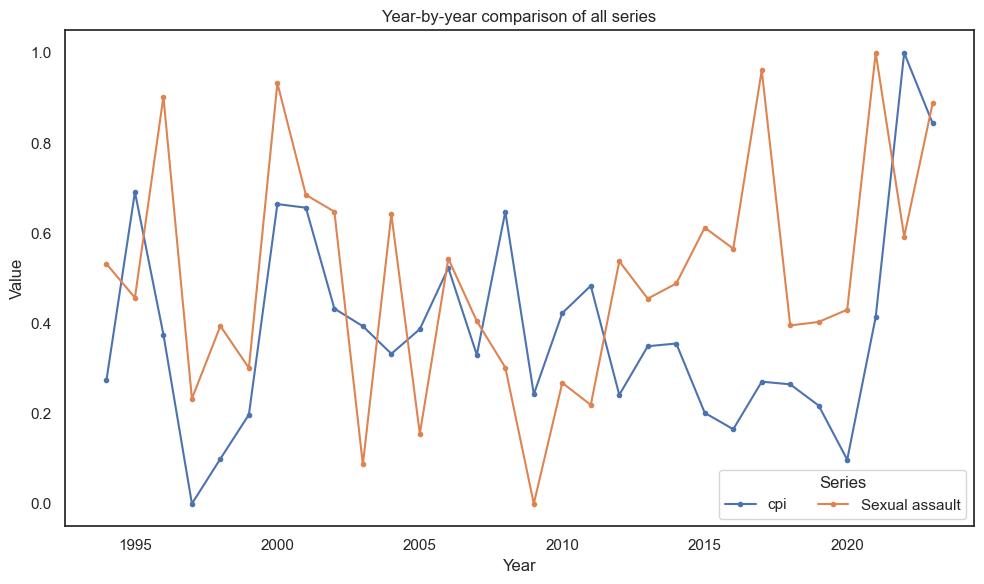

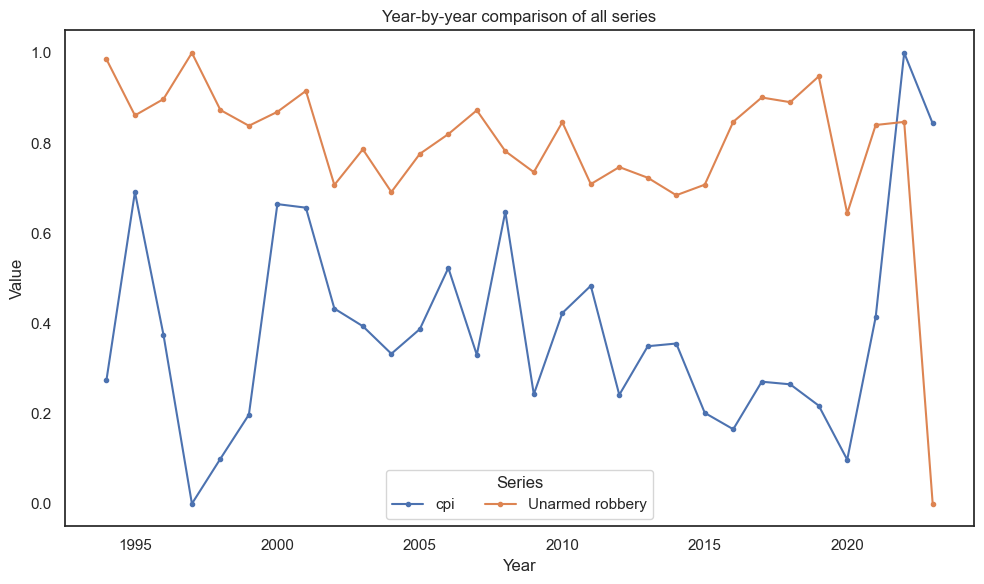

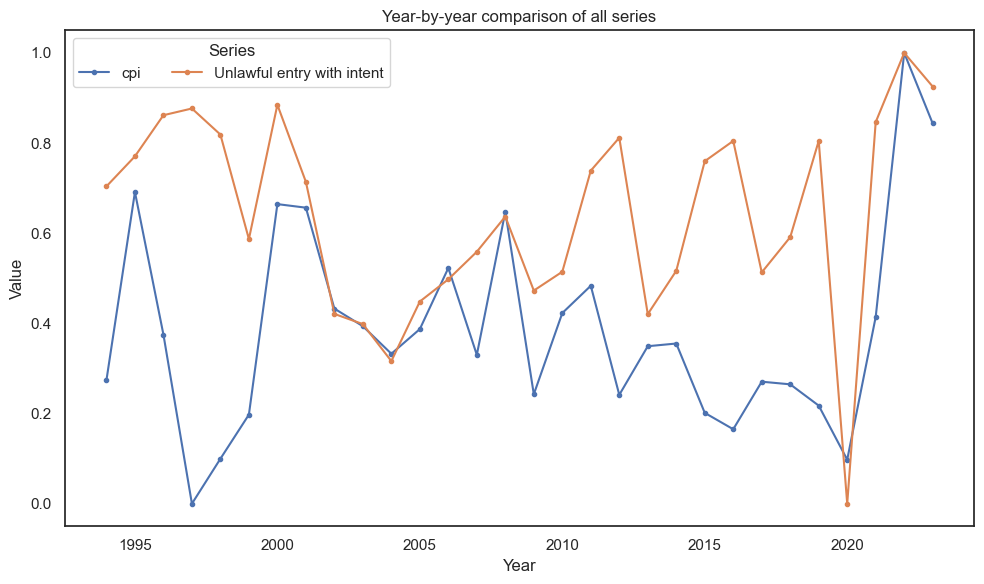

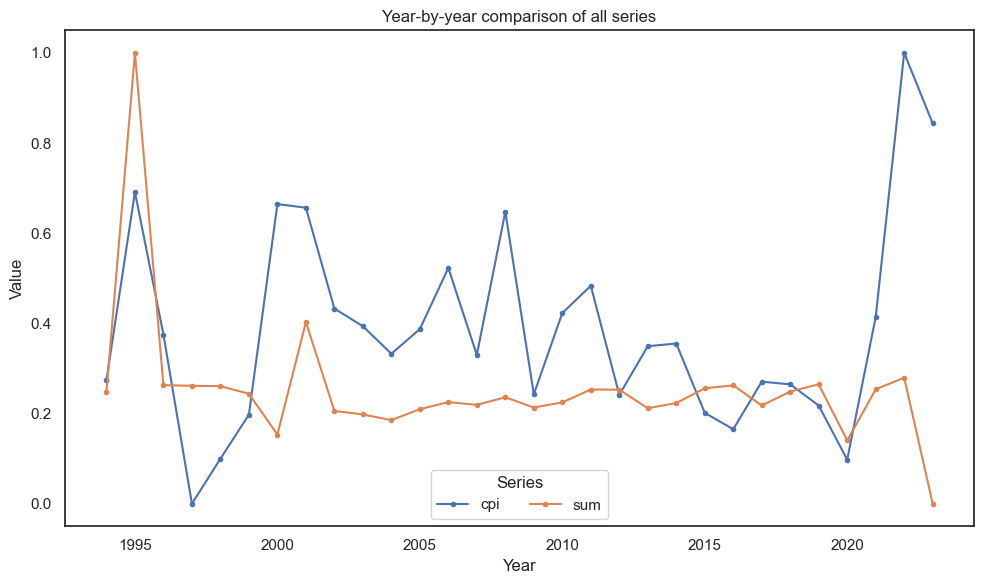

In [46]:
# whether transfer to growth
temp_df = main_df
temp_df = get_pct_change(temp_df)

for i in range(1, len(temp_df.columns)):
    sub_df = sub_df_contains_cpi(temp_df, i)
    sub_df = min_max_norm(sub_df)
    show_df(sub_df)